In [192]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [193]:
df = pd.read_csv("laptop_price.csv", encoding='latin1')

In [194]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [195]:
df.shape

(1303, 13)

In [196]:
df1 = df.copy()

In [197]:
df1 = df1.drop(['laptop_ID','Product'], axis = 1)

In [198]:
df1.isnull().sum()

,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0
Weight,0


In [199]:
df1.duplicated().sum()

np.int64(29)

In [200]:
df1.duplicated().sum()

np.int64(29)

In [201]:
df1.shape

(1303, 11)

In [202]:
df1.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros'],
      dtype='object')

In [203]:
df1['Ram'] = df1['Ram'].astype(str).str.replace('GB', '').astype(int)
df1['Weight'] = df1['Weight'].astype(str).str.replace('kg', '').astype(float)

In [204]:
cat_col = ['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'OpSys']

In [205]:
df_e = pd.get_dummies(df1, columns=cat_col, drop_first=True)

print(type(df_e))

<class 'pandas.core.frame.DataFrame'>


In [206]:
df_e.shape

(1303, 338)

In [207]:
df_e = df_e.astype(int)

In [208]:
df_e.shape

(1303, 338)

In [209]:
df_e.head()

,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,13,8,1,1339,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,13,8,1,898,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,15,8,1,575,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,15,16,1,2537,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,13,8,1,1803,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [210]:
df_e.head()

,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,13,8,1,1339,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,13,8,1,898,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,15,8,1,575,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,15,16,1,2537,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,13,8,1,1803,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [211]:
print(type(df_e))
print(df_e.shape)

<class 'pandas.core.frame.DataFrame'>
(1303, 338)


In [212]:
from sklearn.preprocessing import StandardScaler

num_col = ['Inches', 'Ram', 'Weight']

scaler = StandardScaler()
df_e[num_col] = scaler.fit_transform(df_e[num_col])

In [213]:
df_e.head()

,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,-1.161255,-0.075195,-0.889378,1339,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,-1.161255,-0.075195,-0.889378,898,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0.294363,-0.075195,-0.889378,575,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0.294363,1.498767,-0.889378,2537,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,-1.161255,-0.075195,-0.889378,1803,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [214]:
X = df_e.drop('Price_euros', axis = 1)
y = df_e['Price_euros']

In [215]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [216]:
# Building ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [217]:
model = Sequential()

In [218]:
input_dim = X_train.shape[1]

model.add(Dense(units=128, activation='relu', input_shape=(input_dim,)))
model.add(Dropout(0.2)) # 1st Hidden Layer

model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.2))  # 2nd Hidden Layer

model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))  # 3rd Hidden Layer

model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))  # 4th Hidden Layer

model.add(Dense(units=1, activation='linear')) # Output Layer

In [219]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │        43,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,145 (274.00 KB)

 Trainable params: 70,145 (274.00 KB)

 Non-trainable params: 0 (0.00 B)

In [220]:
early = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

In [221]:
model.compile(optimizer='adam', loss='mean_squared_error',metrics=['mean_absolute_error'])

In [222]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, callbacks=[early])

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1749680.7500 - mean_absolute_error: 1122.4209 - val_loss: 1733807.7500 - val_mean_absolute_error: 1130.8422
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1608815.0000 - mean_absolute_error: 1060.4670 - val_loss: 1274391.2500 - val_mean_absolute_error: 914.2043
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 702078.1250 - mean_absolute_error: 616.4739 - val_loss: 324827.5625 - val_mean_absolute_error: 466.7126
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 279524.9062 - mean_absolute_error: 398.8402 - val_loss: 190521.3594 - val_mean_absolute_error: 287.2668
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 176963.0312 - mean_absolute_error: 296.9655 - val_loss: 166847.8125 - val_mean_absolute_error: 263.0802
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 171567.7188 - mean_absolute_error: 279.9691 - val_loss: 159584.9844 - val_mean_absolute_error: 264.4153
Epoch 7/100
2

In [223]:
y_pred = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [225]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Mean Squared Error: 83704.2890625
Mean Absolute Error: 188.9525909423828
R-squared: 0.8351992964744568


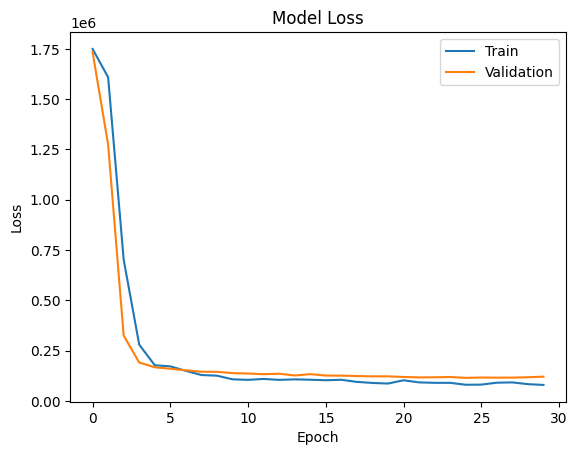

In [227]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

In [228]:
import joblib

# Save ANN model
model.save("ann_laptop_price_model.keras")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature columns
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("All deployment files saved successfully!")

All deployment files saved successfully!


In [229]:
joblib.dump(cat_col, "cat_col.pkl")
joblib.dump(num_col, "num_col.pkl")

['num_col.pkl']